# OpenHealth Price Transparency Analysis

This notebook demonstrates how to access healthcare pricing data using the **OpenHealthDP API** and perform temporal trend analysis to compare costs over time across multiple procedures.

### Prerequisites
- Ensure the OpenHealthDP server is running (usually on `http://localhost:3001`)
- Install dependencies: `pip install requests pandas matplotlib seaborn`

In [1]:
%matplotlib inline
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuration
BASE_URL = "http://localhost:3001/api/v1/transparency"
API_KEY = "AI4H2-PUBLIC-2023-BETA"  # Default beta key

def fetch_procedure_data(procedure_id):
    headers = {"x-api-key": API_KEY}
    params = {"procedureId": procedure_id}
    try:
        response = requests.get(BASE_URL, headers=headers, params=params)
        if response.status_code == 200:
            data = response.json()["data"]
            df = pd.DataFrame(data)
            if not df.empty:
                df['procedure_id'] = procedure_id
            return df
        else:
            print(f"API Error for {procedure_id}: {response.text}")
            return pd.DataFrame()
    except Exception as e:
        print(f"Connection Error for {procedure_id}: {e}")
        return pd.DataFrame()

## 1. Data Inventory & Coverage Matrix
Before analyzing trends, we must verify our **Data Coverage**. We need to know how many providers reported data for each procedure in each year. A "sparse" matrix (missing years or low counts) can lead to misleading trends.

### Data Coverage Matrix (Record Counts per Year)
This table shows the sample size (N) for each procedure by year.


source_year,2018,2019,2020,2021,2022,2023
procedure_id,,,,,,
CPT:45378,77,75,73,86,94,95
CPT:70551,54,60,77,95,107,107
DRG:193,50,50,48,49,51,51
DRG:470,50,49,44,42,38,38
DRG:871,51,51,51,51,51,51


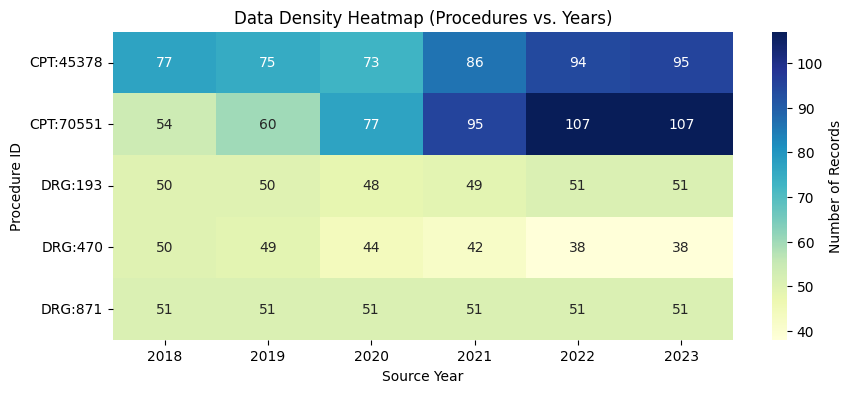

In [2]:
procedures = [
    "CPT:70551", "CPT:45378", # Outpatient
    "DRG:871", "DRG:470", "DRG:193" # Inpatient
]

all_data = []
for pid in procedures:
    df = fetch_procedure_data(pid)
    if not df.empty:
        all_data.append(df)

if all_data:
    full_df = pd.concat(all_data, ignore_index=True)
    
    # Create a Coverage Matrix (Procedure vs Year)
    coverage_matrix = full_df.groupby(['procedure_id', 'source_year']).size().unstack(fill_value=0)
    
    print("### Data Coverage Matrix (Record Counts per Year)")
    print("This table shows the sample size (N) for each procedure by year.")
    display(coverage_matrix)
    
    # Visualizing the coverage density
    plt.figure(figsize=(10, 4))
    sns.heatmap(coverage_matrix, annot=True, fmt="d", cmap="YlGnBu", cbar_kws={'label': 'Number of Records'})
    plt.title("Data Density Heatmap (Procedures vs. Years)")
    plt.ylabel("Procedure ID")
    plt.xlabel("Source Year")
    plt.show()
else:
    print("No data loaded. Check API status.")

## 2. Temporal Trend for MRI Brain (10th/90th Percentiles)
Analysis of a specific procedure with shaded regions showing the **10th to 90th percentile** spread. This helps us see if the market is becoming more or less fragmented over time.

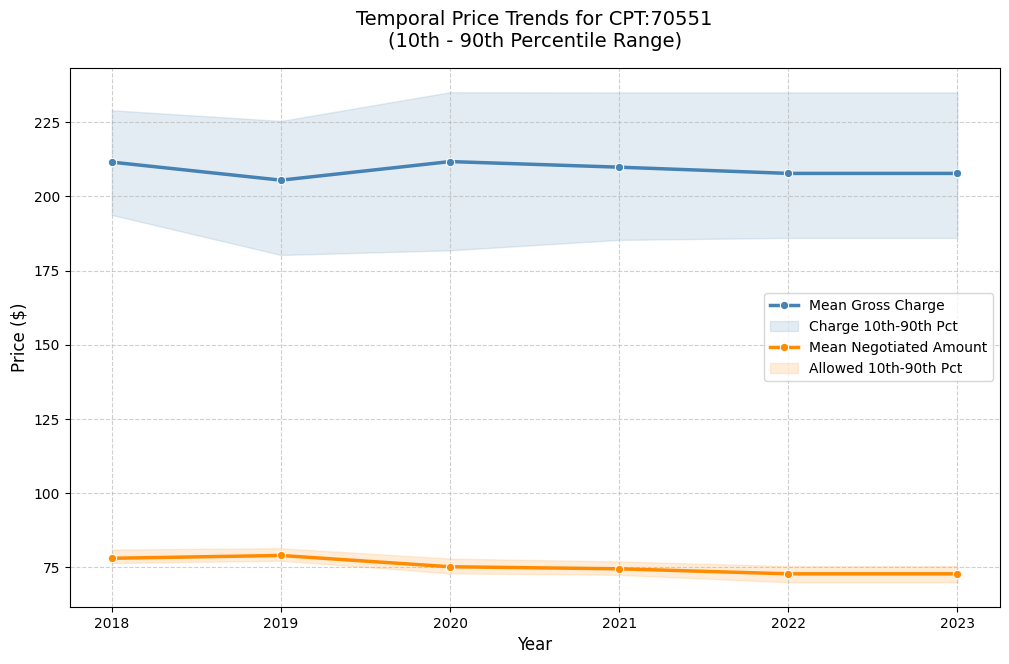

In [3]:
pid = "CPT:70551"
df_single = full_df[full_df['procedure_id'] == pid]

if not df_single.empty and 'source_year' in df_single.columns:
    # Aggregate 10th and 90th percentiles
    stats = df_single.groupby('source_year').agg({
        'avg_charge': ['mean', lambda x: x.quantile(0.10), lambda x: x.quantile(0.90)],
        'avg_allowed': ['mean', lambda x: x.quantile(0.10), lambda x: x.quantile(0.90)]
    })
    stats.columns = ['charge_mean', 'charge_p10', 'charge_p90', 'allowed_mean', 'allowed_p10', 'allowed_p90']
    stats = stats.reset_index()

    plt.figure(figsize=(12, 7))
    
    # Gross Charges
    sns.lineplot(data=stats, x='source_year', y='charge_mean', marker='o', color='steelblue', label='Mean Gross Charge', linewidth=2.5)
    plt.fill_between(stats['source_year'], stats['charge_p10'], stats['charge_p90'], color='steelblue', alpha=0.15, label='Charge 10th-90th Pct')
    
    # Allowed Amounts
    sns.lineplot(data=stats, x='source_year', y='allowed_mean', marker='o', color='darkorange', label='Mean Negotiated Amount', linewidth=2.5)
    plt.fill_between(stats['source_year'], stats['allowed_p10'], stats['allowed_p90'], color='darkorange', alpha=0.15, label='Allowed 10th-90th Pct')
    
    plt.title(f'Temporal Price Trends for {pid}\n(10th - 90th Percentile Range)', fontsize=14, pad=15)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Price ($)', fontsize=12)
    plt.xticks(stats['source_year'].unique())
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

## 3. Comparative Price Trends (All Procedures)
Visualizing the mean **Negotiated (Allowed) Amount** for all procedures on a log-scale. This allows us to compare relative inflation rates across high-cost surgeries and lower-cost imaging.

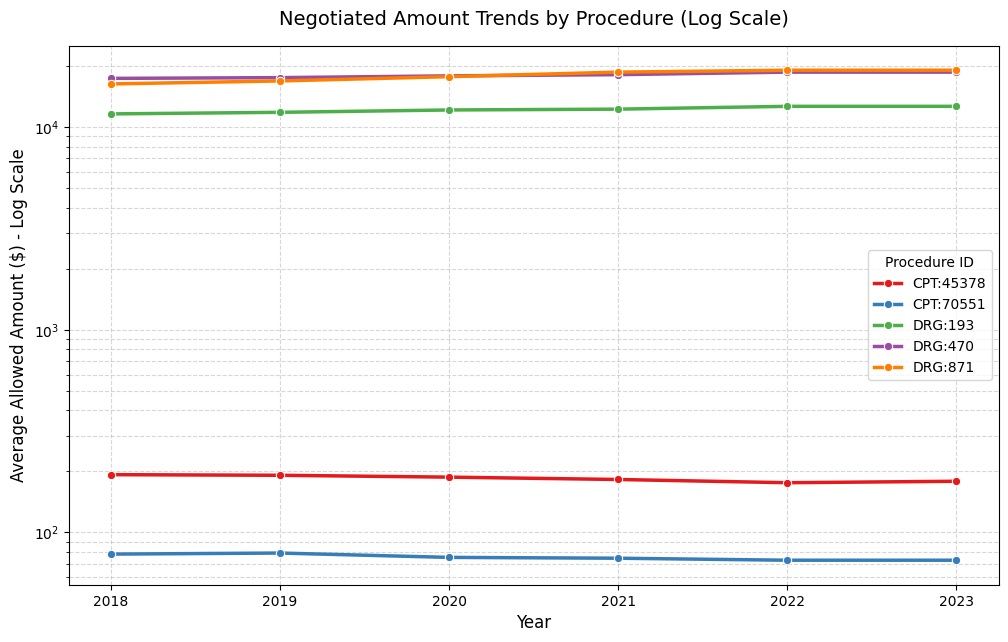

In [4]:
if not full_df.empty:
    # Group by procedure and year
    comp_stats = full_df.groupby(['procedure_id', 'source_year'])['avg_allowed'].mean().reset_index()
    
    plt.figure(figsize=(12, 7))
    sns.lineplot(data=comp_stats, x='source_year', y='avg_allowed', hue='procedure_id', marker='o', palette='Set1', linewidth=2.5)
    
    plt.yscale('log') # Log scale handles heterogeneous price points ($500 vs $50,000)
    plt.title('Negotiated Amount Trends by Procedure (Log Scale)', fontsize=14, pad=15)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Average Allowed Amount ($) - Log Scale', fontsize=12)
    plt.xticks(comp_stats['source_year'].unique())
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.legend(title='Procedure ID')
    plt.show()

## 4. Annual Price Inflation Analysis
Percentage change in **Negotiated (Allowed) Amounts** year-over-year. This table highlights which medical categories are experiencing the fastest cost growth.

In [5]:
if not full_df.empty:
    # Calculate annual mean for each procedure
    ann_mean = full_df.groupby(['procedure_id', 'source_year'])['avg_allowed'].mean().reset_index()
    
    # Calculate % change
    ann_mean['pct_change'] = ann_mean.groupby('procedure_id')['avg_allowed'].pct_change() * 100
    
    # Summary table of inflation
    inflation_pivot = ann_mean.pivot(index='procedure_id', columns='source_year', values='pct_change')
    print("Year-over-Year Inflation (%) for Negotiated Amounts:")
    display(inflation_pivot.round(2))

Year-over-Year Inflation (%) for Negotiated Amounts:


source_year,2018,2019,2020,2021,2022,2023
procedure_id,,,,,,
CPT:45378,NaN,-0.69,-2.09,-2.64,-3.60,1.67
CPT:70551,NaN,1.21,-4.81,-0.93,-2.26,0.00
DRG:193,NaN,1.81,2.72,0.93,3.25,0.00
DRG:470,NaN,0.87,2.01,1.38,2.92,0.00
DRG:871,NaN,3.48,4.96,5.29,2.18,0.00
